# Plot

In [21]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import json

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disabpd.option_context('display.max_columns', 300)le copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [22]:
# Load JSON
with open('chgchg_effs.json') as f:
    dataList = json.load(f)
rows = []
for i,data in enumerate(dataList):
    # Separate scalar fields and list-of-dicts fields
    scalar_fields = {k: v for k, v in data.items() if not isinstance(v, list)}
    list_fields   = {k: v for k, v in data.items() if isinstance(v, list)}

    for field, listOfDicts in list_fields.items():
        for d in listOfDicts:            
            row = scalar_fields.copy()
            row["index"] = i
            row.update(d)
            rows.append(row)

# Convert to DataFrame
df_c1c1 = pd.DataFrame(rows)
column_order = ['mLLP','tau_ns','tau0_ns']
column_order = column_order[:] + [col for col in df_c1c1.columns if col not in column_order[:]]

# Optional: set MultiIndex
df_c1c1 = df_c1c1[column_order]

with open('chgn1_effs.json') as f:
    dataList = json.load(f)
rows = []
for i,data in enumerate(dataList):
    # Separate scalar fields and list-of-dicts fields
    scalar_fields = {k: v for k, v in data.items() if not isinstance(v, list)}
    list_fields   = {k: v for k, v in data.items() if isinstance(v, list)}

    for field, listOfDicts in list_fields.items():
        for d in listOfDicts:            
            row = scalar_fields.copy()
            row.update(d)
            rows.append(row)

# Convert to DataFrame
df_c1n1 = pd.DataFrame(rows)
column_order = ['mLLP','tau_ns','tau0_ns']
column_order = column_order[:] + [col for col in df_c1n1.columns if col not in column_order[:]]

# Optional: set MultiIndex
df_c1n1 = df_c1n1[column_order]

### For each (mLLP,tau) keep only the entry with tau/tau0 closest to 1

In [23]:
for df in [df_c1c1,df_c1n1]:
    keep_indices = []
    for group,df_g in df.groupby(['mLLP','tau_ns']):
        imin = np.argmin(np.abs(1.0-df_g['tau_ns']/df_g['tau0_ns']))
        ii = df_g.index.to_list()[imin]
        keep_indices.append(ii)
    df.drop(index=df[~df.index.isin(keep_indices)].index,inplace=True)
    print(len(df))

300
300


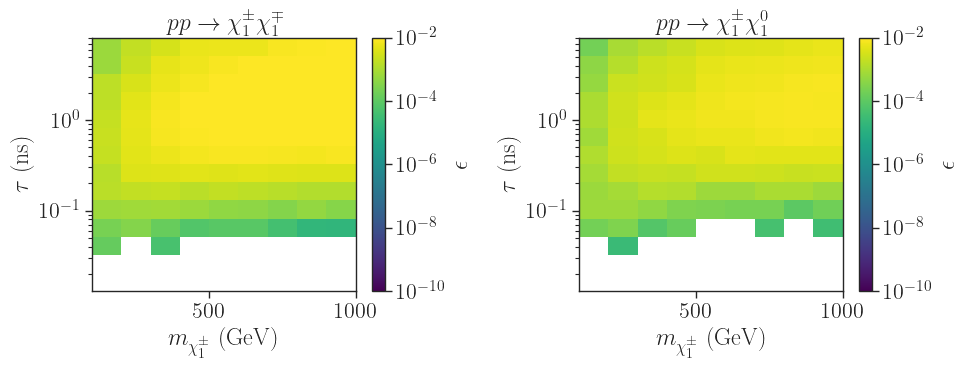

In [24]:
fig,axList =plt.subplots(figsize=(10,4),nrows=1,ncols=2)

labels = [r'$p p \to \chi_1^\pm \chi_1^\mp$',r'$p p \to \chi_1^\pm \chi_1^0$']
for ax,df,label in zip(axList,[df_c1c1,df_c1n1],labels):
    x = df['mLLP']
    y = df['tau_ns']
    z = df['EWK SR']

    # p = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-4,min(z)),vmax=max(z)))
    counts, xedges, yedges, im = ax.hist2d(x,y,bins=[sorted(x),sorted(y)],weights=z, cmap='viridis',
                                           norm=LogNorm(vmin=1e-10,vmax=1e-2))

    
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(label)

# cbar_ax = fig.add_axes([0.99, 0.25, 0.01, 0.6])
# fig.colorbar(p,label=r'$\epsilon$',cax=cbar_ax)
plt.tight_layout()
plt.show()

### Check point

In [65]:
mLLP = 500.0
tau = 0.12
eff_c1c1 =float(df_c1c1.query(f'mLLP == {mLLP} and abs(tau_ns-{tau}) < 0.01').iloc[0]['EWK SR'])
eff_c1n1 =float(df_c1n1.query(f'mLLP == {mLLP} and abs(tau_ns-{tau}) < 0.01').iloc[0]['EWK SR'])
xsecs_c1c1 = np.genfromtxt('xsec_13TeV_pp2chgchg_fb.csv',delimiter=',',names=True)
xsecs_c1n1 = np.genfromtxt('xsec_13TeV_pp2chgn1_fb.csv',delimiter=',',names=True)
im = np.argmin(np.abs(xsecs_c1c1['mass']-mLLP))
xsec_c1c1,xsec_c1c1_error = xsecs_c1c1['xsec'][im],xsecs_c1c1['unc'][im]
im = np.argmin(np.abs(xsecs_c1n1['mass']-mLLP))
xsec_c1n1,xsec_c1n1_error = xsecs_c1n1['xsec'][im],xsecs_c1n1['unc'][im]

# Shift xsecs by 1sigm
xsec_c1c1 = xsec_c1c1-xsec_c1c1_error
xsec_c1n1 = xsec_c1n1-xsec_c1n1_error
xsec_tot = xsec_c1c1+xsec_c1n1
eff_res = (eff_c1c1*xsec_c1c1 + eff_c1n1*xsec_c1n1)/xsec_tot
sigma_UL_atlas_fb = 0.037 # Limit from https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/SUSY-2018-19/tab_08.png
print(f"Effective efficiency = {eff_res:1.3e}")
print(f"Total xsec (fb) = {xsec_tot:1.3e}")
print(f"Visible xsec (fb) = {xsec_tot*eff_res:1.3e}")
print(f"r = {xsec_tot*eff_res/sigma_UL_atlas_fb:1.2f}")


Effective efficiency = 1.055e-03
Total xsec (fb) = 6.237e+01
Visible xsec (fb) = 6.582e-02
r = 1.78
